# Notebook to process lysosomal and mitochondrial morphology from cellprofiler features - this time from a merged cell CSV aready created
Inputs Required
 - Database with cellprofiler outputs
   - Mainly use the Per_Cell table for per-cell features
     - Intensity
     - AreaShape features
     - Ratio of organelle area to total cell area
     - Texture features
     - Granularity features
     - Radial intensity distribution about nucleus
   - May additionally want to use mitochdondria or lysosomes.csv if analyzing these specifically 
     - Note that lysosome segmentation is not perfect (but i'm proud of it)
 - Metadata CSV representing 96-well platemap
   - Long-form table containing passage number, staining conditons, treatments, etc
   - Produced automatically from an 8x12 table with the 96Well_PlateMap code
Outputs
- graphs for individual features
- clustering
## Set your paths here

In [1]:
#Imports
import os
import numpy as np
import pandas as pd
import sqlite3
#plotting
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from scipy import stats

from helpers import *


## Debugging functions


In [2]:
def add_drug_to_group(init_df, group, drug):
    '''
        Add the name of a drug treatment from the "Drug" column to the main "group" column
        
        Returns
            Series object: A series containing the column with the drug added to the group
    '''
    if drug is not None:
        # Replace values in 'col1' with values from 'col2' only if 'col2' is not None or NaN
        df = init_df.copy()
        df[group] = np.where(df[drug].notna(), df[drug], df[group])
        newcol = df[group]

    return newcol

#display(cell_df[["Cell_Mean_Nuclei_AreaShape_Area", "Cell_AreaShape_Area"]])

def cell_filters(df):
    not_empty_df = df[df["Metadata_EmptyImage_Cells"] == 0] 
    normal_cells = not_empty_df[not_empty_df["Cell_Classify_Normal"] ==1] #one nucleus only
    size_filtered_cells = normal_cells[df["Cell_AreaShape_Area"] > df["Cell_Mean_Nuclei_AreaShape_Area"]] #cell area bigger than nuclear area
    final_df = size_filtered_cells.reset_index(drop=True)
    return final_df

def multinucleate_cells(df):
    multinuc_df = df[df["Cell_Classify_multinucleate"] ==1]
    return multinuc_df

#cell_df_2 = cell_filters(cell_df)
#cell_df_2.head()
#filter_df = cell_filters(cell_df)
#print(cell_df.shape, " ", filter_df.shape)
#display(filter_df["Cell_Classify_Normal"])
def well_namer(row, col):
    '''
        Convert row and column numbers to a well name in the format A01, B02, etc.
        
        Args:
            row (int): The row number (1-8)
            col (int): The column number (1-12)
        
        Returns:
            str: Well name in the format A01, B02, etc.
    '''
    well_name = str(chr(ord('@')+ row)) + str(col).rjust(2, '0')  #make the number have a left align, adding a zero
    return well_name

def add_well_metadata(image_df):
    '''
        Add well metadata to the image DataFrame.
        
        Args:
            image_df (DataFrame): DataFrame containing image metadata
        
        Returns:
            DataFrame: Updated DataFrame with well metadata
    '''
    image_df.columns = image_df.columns.str.replace(r'^Image_Metadata_', 'Metadata_', regex=True)
    image_df[["Metadata_WellRow","Metadata_WellColumn","Metadata_Field"]] = image_df["Image_URL_DAPI"].str.extract(r'r(\d{2})c(\d{2})f(\d{2}).tif')
    # Convert extracted columns to int
    image_df["Metadata_WellRow"] = image_df["Metadata_WellRow"].astype(int)
    image_df["Metadata_WellColumn"] = image_df["Metadata_WellColumn"].astype(int)
    image_df["Metadata_Field"] = image_df["Metadata_Field"].astype(int)
    # apply well namer function
    image_df["Metadata_Well"] = image_df.apply(lambda x: well_namer(x["Metadata_WellRow"], x["Metadata_WellColumn"]), axis=1)
    display(image_df[["ImageNumber","Image_URL_DAPI","Metadata_WellRow","Metadata_WellColumn","Metadata_Field","Metadata_Well"]])
    
    return image_df

def update_database_with_well_metadata(db_path):
    '''
        Update the database with well metadata.
        
        Args:
            db_path (str): Path to the database file
    '''
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    # Read Per_Image table
    image_df = pd.read_sql_query("SELECT * FROM Per_Image", conn)
    
    # Add well metadata
    updated_image_df = add_well_metadata(image_df)
    
    # Write updated DataFrame back to the database
    try:
        updated_image_df.to_sql('Per_Image', conn, if_exists='replace', index=False)
        print("Database updated successfully with well metadata.")
    except Exception as e:
        print(f"Error updating database: {e}")
    #cursor.execute("SELECT Metadata_Well FROM Per_Image LIMIT 5;")
    #cursor.fetchall()
    conn.close()

## Import the big csv

In [3]:
#import from a giant csv
csvpath = '/Volumes/AllieS_HD1/Allie Spangaro MSc/CP_output/'
filename = 'total_combined_cell.csv'
combined_cell_df_mitolyso = pd.read_csv(os.path.join(csvpath, filename))
#filter_df = cell_filters(combined_cell_df_mitolyso)
display(combined_cell_df_mitolyso.shape)
#print(cell_df.shape, " ", filter_df.shape)

#combined_cell_df_mitolyso_merged = plate_df_setup(curr_plates, curr_plate_datafolders, parent_dir, ['Cell.csv', 'Nuclei.csv','MergedMitoPerCell.csv','MergedLysoPerCell.csv'])

#display(combined_cell_df_mitolyso_merged)


/var/folders/yd/1fhlg3pn6d74xlj_wkkzgcrc0000gn/T/ipykernel_43626/1496284125.py:4: DtypeWarning: Columns (1104,1105,1184,1185,1217,1218,1265,1266,1283) have mixed types. Specify dtype option on import or set low_memory=False.
  combined_cell_df_mitolyso = pd.read_csv(os.path.join(csvpath, filename))


(75440, 1295)

In [4]:
extra_data = pd.read_csv("/Volumes/AllieS_HD1/Allie Spangaro MSc/CP_output/data_with_extraRow1.csv")
# Get ImageNumbers from Replicate_Number == 5 subset
rep5_image_numbers = combined_cell_df_mitolyso.loc[combined_cell_df_mitolyso["Replicate_Number"] == 5, "ImageNumber"]

# Filter extra_data to exclude those ImageNumbers
extra_data_mask = extra_data[~extra_data["ImageNumber"].isin(rep5_image_numbers)]
display(extra_data_mask.shape)
# Concatenate the filtered extra_data to the main dataframe
combined_cell_df_mitolyso = pd.concat([combined_cell_df_mitolyso, extra_data_mask], ignore_index=True)

display(combined_cell_df_mitolyso.shape)
display(combined_cell_df_mitolyso.head())

/var/folders/yd/1fhlg3pn6d74xlj_wkkzgcrc0000gn/T/ipykernel_43626/2267575536.py:1: DtypeWarning: Columns (1828) have mixed types. Specify dtype option on import or set low_memory=False.
  extra_data = pd.read_csv("/Volumes/AllieS_HD1/Allie Spangaro MSc/CP_output/data_with_extraRow1.csv")


(4531, 1833)

(79971, 1838)

,ImageNumber,Cell_Number_Object_Number,Cell_AreaShape_Area,Cell_AreaShape_BoundingBoxArea,Cell_AreaShape_BoundingBoxMaximum_X,Cell_AreaShape_BoundingBoxMaximum_Y,Cell_AreaShape_BoundingBoxMinimum_X,Cell_AreaShape_BoundingBoxMinimum_Y,Cell_AreaShape_Center_X,Cell_AreaShape_Center_Y,...,MergedNucleiPerCell_AreaShape_Zernike_8_6,MergedNucleiPerCell_AreaShape_Zernike_8_8,MergedNucleiPerCell_AreaShape_Zernike_9_1,MergedNucleiPerCell_AreaShape_Zernike_9_3,MergedNucleiPerCell_AreaShape_Zernike_9_5,MergedNucleiPerCell_AreaShape_Zernike_9_7,MergedNucleiPerCell_AreaShape_Zernike_9_9,MergedNucleiPerCell_Location_Center_X,MergedNucleiPerCell_Location_Center_Y,MergedNucleiPerCell_Parent_Nuclei
0,1,1,180419.0,631174.0,1563.0,787.0,761.0,0.0,1234.488036,309.368609,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,188312.0,751410.0,2160.0,990.0,1401.0,0.0,1837.779063,499.182803,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,333451.0,703273.0,2089.0,1441.0,1392.0,432.0,1685.976407,996.159535,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,1,13455.0,18560.0,281.0,305.0,136.0,177.0,211.544482,235.770643,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,13,1,69381.0,90201.0,1825.0,377.0,1544.0,56.0,1682.658523,214.187659,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
unique_combinations = combined_cell_df_mitolyso[['Replicate_Number', 'PassageNumber']].drop_duplicates()

combos = list(unique_combinations.itertuples(index=False, name=None))
display(sorted(combos))

[(1, 6),
 (2, 6),
 (2, 9),
 (2, 12),
 (2, 14),
 (2, 17),
 (2, 20),
 (3, 8),
 (3, 10),
 (3, 13),
 (3, 15),
 (3, 18),
 (3, 21),
 (4, 7),
 (4, 10),
 (4, 12),
 (4, 16),
 (4, 18),
 (4, 20),
 (4, 24),
 (5, 7),
 (5, 10),
 (5, 14),
 (5, 16),
 (5, 18),
 (5, 22),
 (5, 25),
 (5, 27),
 (5, 29),
 (6, 8),
 (6, 9),
 (6, 10),
 (6, 13),
 (6, 16),
 (6, 17),
 (6, 19),
 (6, 20),
 (6, 24),
 (6, 27),
 (6, 30),
 (7, 8),
 (7, 12),
 (7, 13),
 (7, 15),
 (7, 17),
 (7, 18),
 (7, 20),
 (7, 22),
 (7, 24),
 (7, 27),
 (7, 29)]

### Filter out the poorly segmented cells and rename the columns so I don't have to change the old code

In [6]:
display(combined_cell_df_mitolyso.shape)
filtered_df = cell_filters(combined_cell_df_mitolyso)
filtered_df.columns = filtered_df.columns.str.replace(r'^Cell_', '', regex=True)

# Display columns containing 'Distance'
distance_cols = [col for col in filtered_df.columns if 'Distance' in col]
display(distance_cols)

(79971, 1838)

/var/folders/yd/1fhlg3pn6d74xlj_wkkzgcrc0000gn/T/ipykernel_43626/4042060021.py:21: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  size_filtered_cells = normal_cells[df["Cell_AreaShape_Area"] > df["Cell_Mean_Nuclei_AreaShape_Area"]] #cell area bigger than nuclear area


['Mean_Lysosomes_Distance_Centroid_Cell',
 'Mean_Lysosomes_Distance_Centroid_Nuclei',
 'Mean_Lysosomes_Distance_Minimum_Cell',
 'Mean_Lysosomes_Distance_Minimum_Nuclei',
 'Mean_Mitochondria_Distance_Centroid_Cell',
 'Mean_Mitochondria_Distance_Centroid_Nuclei',
 'Mean_Mitochondria_Distance_Minimum_Cell',
 'Mean_Mitochondria_Distance_Minimum_Nuclei',
 'Mean_Nuclei_Distance_Centroid_Cell',
 'Mean_Nuclei_Distance_Minimum_Cell']

In [7]:
#display(combined_cell_df_mitolyso[['Cell_AreaShape_Area', 'Cell_Children_Mitochondria_Count','Cell_Mean_Mitochondria_AreaShape_Area']])
display(filtered_df[['AreaShape_Area', 'Children_Mitochondria_Count','Mean_Mitochondria_AreaShape_Area']])

,AreaShape_Area,Children_Mitochondria_Count,Mean_Mitochondria_AreaShape_Area
0,180419.0,214,151.079439
1,188312.0,289,141.937716
2,333451.0,276,151.054348
3,13455.0,37,66.270270
4,69381.0,113,148.460177
...,...,...,...
55686,594665.0,588,91.132653
55687,103884.0,87,123.045977
55688,108126.0,99,128.636364
55689,182422.0,150,111.453333



# Define the cell features


In [8]:
#Add extra columns 
def proportion_area_occupied_per_cell(df, compartment):
    #proportion of area occupied = children * mean organelle area / cell area
    colname = 'Total_Area_Proportion_' + compartment + '_Per_Cell'
    
    #children = 'Children_' + compartment + '_Count'
    #mean_organelle_area = 'Mean_'+ compartment + '_AreaShape_Area'
    organelle_area = compartment + '_AreaShape_Area'
    cell_area = 'AreaShape_Area'
    #df[colname] = df.apply(lambda x: (x[children] * x[mean_organelle_area]) / x[cell_area], axis=1)
    df[colname] = df.apply(lambda x: (x[organelle_area]) / x[cell_area], axis=1)
    return df[colname]

def mean_intesity_per_compartment_per_cell(df,compartment, name, tag, math=None):
    # Calculate the mean intensity of each compartment per cell
    #mean_intesity_per_compartment = integrated / (children*mean_area)
    colname = 'MeanIntensity_Per_' + compartment + '_Per_Cell'
    integrated = 'Intensity_IntegratedIntensity_' + tag
    #children = 'Children_' + compartment + '_Count'
    #mean_area = 'Mean_'+ compartment + '_AreaShape_Area'
    total_organelle_area = name + '_AreaShape_Area'
    total_organelle_area = math if math is not None else total_organelle_area
    df[colname] = df.apply(lambda x: x[integrated] / x[total_organelle_area], axis=1)
    return df[colname]

combined_cell_df_mitolyso_merged = filtered_df.copy()

# combined_cell_df_mitolyso_merged["Mean_Mitochondria_Area_PerCell_Ratio"]  = proportion_area_occupied_per_cell(combined_cell_df_mitolyso_merged, "MergedMitoPerCell")
# combined_cell_df_mitolyso_merged["Mean_Lysosomes_Area_PerCell_Ratio"]  = proportion_area_occupied_per_cell(combined_cell_df_mitolyso_merged, "MergedLysoPerCell")

# combined_cell_df_mitolyso_merged["MeanIntensity_Lysosomes_PerCell_Ratio"] = mean_intesity_per_compartment_per_cell(combined_cell_df_mitolyso_merged, "Lysosomes", "MergedLysoPerCell", "LAMP1")
# combined_cell_df_mitolyso_merged["MeanIntensity_Mitochondria_PerCell_Ratio"] = mean_intesity_per_compartment_per_cell(combined_cell_df_mitolyso_merged, "Mitochondria", "MergedMitoPerCell", "MitoTracker")

# Calculate the total area occupied by mitochondria and lysosomes per cell
combined_cell_df_mitolyso_merged["Math_Total_Mitochondria_AreaShape_Area_PerCell"] = combined_cell_df_mitolyso_merged["Children_Mitochondria_Count"] * combined_cell_df_mitolyso_merged["Mean_Mitochondria_AreaShape_Area"]
combined_cell_df_mitolyso_merged["Math_Total_Lysosomes_AreaShape_Area_PerCell"] = combined_cell_df_mitolyso_merged["Children_Lysosomes_Count"] * combined_cell_df_mitolyso_merged["Mean_Lysosomes_AreaShape_Area"]

#Total intensity per cell based on ingegrated instensity if I don't already have the merged area
combined_cell_df_mitolyso_merged["Corr_MeanIntensity_Lysosomes_PerCell_Ratio"] = mean_intesity_per_compartment_per_cell(combined_cell_df_mitolyso_merged, "Lysosomes", "MergedLysoPerCell", "LAMP1", math="Math_Total_Lysosomes_AreaShape_Area_PerCell")
combined_cell_df_mitolyso_merged["Corr_MeanIntensity_Mitochondria_PerCell_Ratio"] = mean_intesity_per_compartment_per_cell(combined_cell_df_mitolyso_merged, "Mitochondria", "MergedMitoPerCell", "MitoTracker", math="Math_Total_Mitochondria_AreaShape_Area_PerCell")

# Corrected mitochondria and lysosomes counts per cell area
combined_cell_df_mitolyso_merged["Corr_Children_Mitochondria_Count_PerCell_Area"] = combined_cell_df_mitolyso_merged["Children_Mitochondria_Count"] / combined_cell_df_mitolyso_merged["AreaShape_Area"]
combined_cell_df_mitolyso_merged["Corr_Children_Lysosomes_Count_PerCell_Carea"] = combined_cell_df_mitolyso_merged["Children_Lysosomes_Count"] / combined_cell_df_mitolyso_merged["AreaShape_Area"]

#Corrected organelle area ratio per cell ratio
combined_cell_df_mitolyso_merged["Corr_Area_PerCell_Ratio_Mitochondria"] = combined_cell_df_mitolyso_merged["Math_Total_Mitochondria_AreaShape_Area_PerCell"] / combined_cell_df_mitolyso_merged["AreaShape_Area"]
combined_cell_df_mitolyso_merged["Corr_Area_PerCell_Ratio_Lysosomes"] = combined_cell_df_mitolyso_merged["Math_Total_Lysosomes_AreaShape_Area_PerCell"] / combined_cell_df_mitolyso_merged["AreaShape_Area"]

# Ratio of centroid distance to minimum distance for mitochondria and lysosomes
combined_cell_df_mitolyso_merged["Corr_QC_Ratio_Mitochondria"] = combined_cell_df_mitolyso_merged["Mean_Mitochondria_Distance_Centroid_Nuclei"] / combined_cell_df_mitolyso_merged["Mean_Mitochondria_Distance_Minimum_Cell"]
combined_cell_df_mitolyso_merged["Corr_QC_Ratio_Lysosomes"] = combined_cell_df_mitolyso_merged["Mean_Lysosomes_Distance_Centroid_Nuclei"] / combined_cell_df_mitolyso_merged["Mean_Lysosomes_Distance_Minimum_Cell"]

display(combined_cell_df_mitolyso_merged[["Children_Mitochondria_Count","Mean_Mitochondria_AreaShape_Area","Math_Total_Mitochondria_AreaShape_Area_PerCell","Corr_MeanIntensity_Mitochondria_PerCell_Ratio","Corr_Children_Mitochondria_Count_PerCell_Area","Corr_Area_PerCell_Ratio_Mitochondria","Corr_QC_Ratio_Mitochondria"]])


#Note: use the "Corr_" flag to get the corrected values
#display(combined_cell_df_mitolyso_merged[["Passage Group","Mean_Lysosomes_Intensity_MeanIntensity_LAMP1","MeanIntensity_Mitochondria_PerCell_Ratio","MeanIntensity_Lysosomes_PerCell_Ratio","Mean_Lysosomes_Area_PerCell_Ratio","Mean_Mitochondria_Area_PerCell_Ratio","Math_Total_Mitochondria_AreaShape_Area_PerCell","Math_Total_Lysosomes_AreaShape_Area_PerCell"]])

,Children_Mitochondria_Count,Mean_Mitochondria_AreaShape_Area,Math_Total_Mitochondria_AreaShape_Area_PerCell,Corr_MeanIntensity_Mitochondria_PerCell_Ratio,Corr_Children_Mitochondria_Count_PerCell_Area,Corr_Area_PerCell_Ratio_Mitochondria,Corr_QC_Ratio_Mitochondria
0,214,151.079439,32331.0,13741.953481,0.001186,0.179200,6.685903
1,289,141.937716,41020.0,12516.329449,0.001535,0.217830,7.931514
2,276,151.054348,41691.0,20269.846490,0.000828,0.125029,3.365930
3,37,66.270270,2452.0,6577.353181,0.002750,0.182237,1.889028
4,113,148.460177,16776.0,12851.888948,0.001629,0.241795,2.297902
...,...,...,...,...,...,...,...
55686,588,91.132653,53586.0,28358.648304,0.000989,0.090111,3.170653
55687,87,123.045977,10705.0,26539.018029,0.000837,0.103048,2.675710
55688,99,128.636364,12735.0,29757.568983,0.000916,0.117779,1.495818
55689,150,111.453333,16718.0,25715.683993,0.000822,0.091645,3.069323


In [9]:

#file_path = '/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/Cellcsv_columns.txt'
#pairs_samples = [('P6-8', 'P9-10'), ('P6-8', 'P11-13'), ('P6-8', 'P14-16'), ('P6-8', 'P17-18'),
# ('P6-8', 'P20-21'), ('P6-8', 'P22-24'), ('P9-10', 'P11-13'), ('P9-10', 'P14-16'), ('P9-10', 'P17-18'), 
# ('P9-10', 'P20-21'), ('P9-10', 'P22-24'), ('P11-13', 'P14-16'), ('P11-13', 'P17-18'), ('P11-13', 
# 'P20-21'), ('P11-13', 'P22-24'), ('P14-16', 'P17-18'), ('P14-16', 'P20-21'), ('P14-16', 'P22-24'),
# ('P17-18', 'P20-21'), ('P17-18', 'P22-24'), ('P20-21', 'P22-24')]
columns_list = define_cell_features(combined_cell_df_mitolyso_merged)
def define_cell_features(df):
    # Get the columns of the dataframe
    columns_list = df.columns.tolist()
    columns_list = [col for col in columns_list if 'Metadata' not in col and 'FileName' not in col and 'PathName' not in col and pd.api.types.is_numeric_dtype(df[col])]
    old_columns_list = columns_list = [col for col in columns_list if 'Metadata' not in col and 'FileName' not in col and 'PathName' not in col]
    print("Original columns:", len(old_columns_list), "Filtered columns:", len(columns_list))
    return columns_list

mito_features = make_feature_dict([col for col in columns_list if 'Mito' in col or "Mitochondria" in col])
lyso_features = make_feature_dict([col for col in columns_list if 'Lysosome' in col or 'LAMP1' in col or 'Lyso' in col])
nuc_features = make_feature_dict([col for col in columns_list if 'Nuc' in col or 'DAPI' in col])
cell_features = make_feature_dict([col for col in columns_list if "AreaShape" in col and "Mito" not in col and "Lyso" not in col and 'LAMP1' not in col and 'Nuc' not in col and 'DAPI'not in col and 'Metadata' not in col and 'FileName' not in col and 'PathName' not in col])
print(columns_list)


['ImageNumber', 'Number_Object_Number', 'AreaShape_Area', 'AreaShape_BoundingBoxArea', 'AreaShape_BoundingBoxMaximum_X', 'AreaShape_BoundingBoxMaximum_Y', 'AreaShape_BoundingBoxMinimum_X', 'AreaShape_BoundingBoxMinimum_Y', 'AreaShape_Center_X', 'AreaShape_Center_Y', 'AreaShape_Compactness', 'AreaShape_ConvexArea', 'AreaShape_Eccentricity', 'AreaShape_EquivalentDiameter', 'AreaShape_EulerNumber', 'AreaShape_Extent', 'AreaShape_FormFactor', 'AreaShape_MajorAxisLength', 'AreaShape_MaxFeretDiameter', 'AreaShape_MaximumRadius', 'AreaShape_MeanRadius', 'AreaShape_MedianRadius', 'AreaShape_MinFeretDiameter', 'AreaShape_MinorAxisLength', 'AreaShape_Orientation', 'AreaShape_Perimeter', 'AreaShape_Solidity', 'AreaShape_Zernike_0_0', 'AreaShape_Zernike_1_1', 'AreaShape_Zernike_2_0', 'AreaShape_Zernike_2_2', 'AreaShape_Zernike_3_1', 'AreaShape_Zernike_3_3', 'AreaShape_Zernike_4_0', 'AreaShape_Zernike_4_2', 'AreaShape_Zernike_4_4', 'AreaShape_Zernike_5_1', 'AreaShape_Zernike_5_3', 'AreaShape_Zernik

## Feature lists here:

In [10]:
feature_dicts = [mito_features, lyso_features, nuc_features, cell_features]
feature_names = ["Mitochondria Features", "Lysosome Features", "Nucleus Features", "Cell Features"]

# Define the output file path
output_file_path = 'allfeatures_file.md'

# Open the file in write mode
with open(output_file_path, 'w') as file:
    for feature_name, feature_dict in zip(feature_names, feature_dicts):
        file.write(f"# {feature_name}\n\n")
        for feature_type, features in feature_dict.items():
            file.write(f"## {feature_type.capitalize()}\n")
            for feature in features:
                file.write(f"- {feature}\n")
            file.write("\n")
            
print(f"List has been written to {output_file_path}")


List has been written to allfeatures_file.md


sns.pairplot(cell_df, hue='Passage Group', vars=mito_features['radialdistribution'], diag_kind='kde', plot_kws={'alpha':0.5})
plt.show()

In [11]:
#Debug to check for mixed types in columns
for col in combined_cell_df_mitolyso_merged.columns:
    types = combined_cell_df_mitolyso_merged[col].apply(type).value_counts()
    if len(types) > 1:
        print(f"Column '{col}' has mixed types: {types}")

Column 'Image_FileName_Phalloidin' has mixed types: Image_FileName_Phalloidin
<class 'str'>      53618
<class 'float'>     2073
Name: count, dtype: int64
Column 'Image_FileName_Phalloidin_MAX' has mixed types: Image_FileName_Phalloidin_MAX
<class 'str'>      53618
<class 'float'>     2073
Name: count, dtype: int64
Column 'Image_MD5Digest_Phalloidin' has mixed types: Image_MD5Digest_Phalloidin
<class 'str'>      53618
<class 'float'>     2073
Name: count, dtype: int64
Column 'Image_MD5Digest_Phalloidin_MAX' has mixed types: Image_MD5Digest_Phalloidin_MAX
<class 'str'>      53618
<class 'float'>     2073
Name: count, dtype: int64
Column 'Image_PathName_Phalloidin' has mixed types: Image_PathName_Phalloidin
<class 'str'>      53618
<class 'float'>     2073
Name: count, dtype: int64
Column 'Image_PathName_Phalloidin_MAX' has mixed types: Image_PathName_Phalloidin_MAX
<class 'str'>      53618
<class 'float'>     2073
Name: count, dtype: int64
Column 'Image_URL_Phalloidin' has mixed types: I

# Functions for Data Analysis
calulcate normalizations, remove extreme left outliers, etc

## Normalize features to control (Passage 6-8)

In [12]:
curr_plates = ["20240313_rep01","20240326_rep02","20241018_rep03", "20241112_rep04", "20250328_rep05", "20250410_rep06", "20250501_rep07"] #"20240313_rep01_output","20240326_rep02_output"

#print(combined_cell_df_mitolyso_merged.iloc["*","3f9f05979b4d963d3a416940cd146486c35afd73ff8824950945744285caf345b27996985b25de4f280bbe6380ecd3bdb27996985b25de4f280bbe6380ecd3bdaac39e649e9e480b6aa7e043c7ae0740aac39e649e9e480b6aa7e043c7ae0740ebad8781c113930a511fb1e0b33a5ae1ebad8781c113930a511fb1e0b33a5ae1a6ca8186980a3310d2f7e3d35512fcb3a6ca8186980a3310d2f7e3d35512fcb3c3b031fa1953fe9aed603e94b738cd8dc3b031fa1953fe9aed603e94b738cd8df08d58956a263e00e263dbe462b2b8781c992d8f3dd23b778820570de386ab371c992d8f3dd23b778820570de386ab371c992d8f3dd23b778820570de386ab371c992d8f3dd23b778820570de386ab37b4de0c127359612d367afa1651150c8fb4de0c127359612d367afa1651150c8fb4de0c127359612d367afa1651150c8f6b0e15f67abc6df786bf563bc136c3676b0e15f67abc6df786bf563bc136c3676b0e15f67abc6df786bf563bc136c3674a8539031734babcfd06ff30311dbf064a8539031734babcfd06ff30311dbf065918ba3f0a658eec695b9622d9b20547be25a504ff9c89fe118269e9bacab62e3f51d4573daea38cf97711a9273f5ea5155a754ccadd310a7a08caf6dfb4b2b8ca83e03b639c81a341d51d0c7ddff9ea060bc1e34e6f5eb7e3e6b302803a27ca060bc1e34e6f5eb7e3e6b302803a27ca8f3d782190481b6e951c89cc6d8ec2278f3d782190481b6e951c89cc6d8ec2278f3d782190481b6e951c89cc6d8ec2278f3d782190481b6e951c89cc6d8ec2278f3d782190481b6e951c89cc6d8ec22703397b32121e5f601a63e09d3aac334803397b32121e5f601a63e09d3aac33483d056f026c80c5ae4e7432aa1aa370bcadb33dceaa2f3a88b5f8bd16cc89e0c8fe3594b08af4a6536ac08d8b57a23de7e4f270ab1aed64ab67cc2525f78a7b20afffb56f4b746063b8425c7e265e2eaba5ae3e58d97a40077c5fdf1b46d9ba10a5ae3e58d97a40077c5fdf1b46d9ba10a5ae3e58d97a40077c5fdf1b46d9ba10a5ae3e58d97a40077c5fdf1b46d9ba105f4f978e715ee311af26d2fdabe1c7135f4f978e715ee311af26d2fdabe1c713e1865dce5f347eb6f67db5a65479d1b8e1865dce5f347eb6f67db5a65479d1b8e1865dce5f347eb6f67db5a65479d1b8e1865dce5f347eb6f67db5a65479d1b8e1865dce5f347eb6f67db5a65479d1b869980026743a730b2867acfd8ad94b1169980026743a730b2867acfd8ad94b11"])
def normalize_to_control(df, feature, norm_column = 'AgeGroup'):
    '''
    Normalize a feature to the control group (AgeGroup = 0) for each plate.
    Args:
        df (DataFrame): The DataFrame containing the feature to be normalized.
        feature (str): The name of the feature column to normalize.
        norm_column (str): The column used to identify the control group (default is 'AgeGroup').'`
    Returns:
        Series: A Series containing the normalized feature values.
    '''
    # Take the t0 df - lowest passage data point
    t0_df = df[df[norm_column]==0]
    treatment_df = df[[feature, norm_column]].copy()

    #calculate the mean
    mean_zero = t0_df[feature].mean()
    # Check for non-numeric values
    if not pd.api.types.is_numeric_dtype(treatment_df[feature]):
        print(f"[normalize_to_control] WARNING: {feature} is not numeric!")
    #now update the column to have all rows dividied by the mean of group 0
    treatment_df["norm_" + feature] = treatment_df[feature] / mean_zero  
    #return the normalized feature columnn
    return treatment_df["norm_" + feature]

def normalize_features(df, feature_list):
    '''
    Normalize the features in the DataFrame to the control (age group 0) for each plate.
    Args:
        df (DataFrame): The DataFrame containing the features to be normalized.
        feature_list (list): A list of feature column names to normalize.
    Returns:
        DataFrame: A DataFrame with normalized features for each plate.
    '''
    # Normalize the features to the control (age group 0) for each plate
    norm_df = df.copy()
    for feature in feature_list:
        #print('Normalizing feature: ', feature, '...', norm_df[feature].values[0])
        norm_df[feature] = normalize_to_control(df, feature)
        #print('Normalized feature: ', feature, '...', norm_df[feature].values[0])
    return norm_df


def apply_feature_normalization(df, feature_dict, curr_plates):
    '''
    Apply feature normalization to the DataFrame for each plate in a list of plates.
    Args:
        df (DataFrame): The DataFrame containing the features to be normalized.
        feature_dict (dict): A dictionary containing lists of feature columns to normalize.
        curr_plates (list): A list of plate names to apply normalization to.
    Returns:
        DataFrame: A DataFrame with normalized features for each plate.
    '''
    # Normalize the features to the control (age group 0) for each plate
    norm_cell_df = df.copy()
    for plate in curr_plates:
        curr_plate_df = norm_cell_df[norm_cell_df['Metadata_Plate'] == plate].copy()
        for feature_type in feature_dict:
            #get the normalized features, locate the corresponding features on the plate, and replace them on that plate to the plate
            curr_plate_features_df = normalize_features(curr_plate_df, feature_dict[feature_type])
            curr_plate_df.loc[:, feature_dict[feature_type]] = curr_plate_features_df[feature_dict[feature_type]].astype(float)
        norm_cell_df.loc[norm_cell_df['Metadata_Plate'] == plate] = curr_plate_df
    return norm_cell_df

norm_cell_df = combined_cell_df_mitolyso_merged.copy()
print("Before conversion: AgeGroup dtype:", norm_cell_df["AgeGroup"].dtype)
print("Unique AgeGroup values:", norm_cell_df["AgeGroup"].unique())

norm_cell_df["AgeGroup"] = pd.to_numeric(norm_cell_df["AgeGroup"], errors='raise')

print("After conversion: AgeGroup dtype:", norm_cell_df["AgeGroup"].dtype)
print("Unique AgeGroup values after conversion:", norm_cell_df["AgeGroup"].unique())
#display(norm_cell_df["AgeGroup"].value_counts())

norm_cell_df_cell = apply_feature_normalization(norm_cell_df, cell_features, curr_plates).copy()
norm_cell_df_nuc = apply_feature_normalization(norm_cell_df_cell, nuc_features, curr_plates).copy()
norm_cell_df_mito = apply_feature_normalization(norm_cell_df_nuc, mito_features, curr_plates).copy()
norm_cell_df_mitolyso = apply_feature_normalization(norm_cell_df_mito, lyso_features, curr_plates)

#watch out - merged df might be clipping off all of the features

Before conversion: AgeGroup dtype: float64
Unique AgeGroup values: [3. 1. 8. 7. 6. 5. 4. 2. 0. 9.]
After conversion: AgeGroup dtype: float64
Unique AgeGroup values after conversion: [3. 1. 8. 7. 6. 5. 4. 2. 0. 9.]


/var/folders/yd/1fhlg3pn6d74xlj_wkkzgcrc0000gn/T/ipykernel_43626/3010102852.py:63: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.93661972 0.26760563 0.26760563 0.26760563 0.40140845 0.40140845
 1.07042254 1.07042254 1.33802817 1.33802817 1.07042254 1.07042254
 1.07042254 0.93661972 0.93661972 0.93661972 0.93661972 1.20422535
 1.20422535 1.20422535 0.66901408 0.66901408 0.66901408 0.40140845
 0.40140845 0.53521127 0.8028169  1.20422535 0.66901408 0.93661972
 1.47183099 1.47183099 1.33802817 1.33802817 1.33802817 1.33802817
 1.33802817 0.66901408 0.66901408 1.07042254 0.8028169  1.20422535
 1.33802817 1.20422535 1.47183099 1.47183099 1.47183099 1.47183099
 0.53521127 0.53521127 1.33802817 1.33802817 1.33802817 1.33802817
 1.33802817 0.93661972 0.93661972]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  curr_plate_df.loc[:, feature_dict[feature_type]] = curr_plate_features_

In [13]:
norm_cell_df_mitolyso.loc[norm_cell_df_mitolyso['Passage Group'] == 'P6-8'].describe()
#norm_cell_df_mitolyso.describe()


,ImageNumber,Number_Object_Number,AreaShape_Area,AreaShape_BoundingBoxArea,AreaShape_BoundingBoxMaximum_X,AreaShape_BoundingBoxMaximum_Y,AreaShape_BoundingBoxMinimum_X,AreaShape_BoundingBoxMinimum_Y,AreaShape_Center_X,AreaShape_Center_Y,...,MeanIntensity_Per_Lysosomes_Per_Cell,Corr_MeanIntensity_Lysosomes_PerCell_Ratio,MeanIntensity_Per_Mitochondria_Per_Cell,Corr_MeanIntensity_Mitochondria_PerCell_Ratio,Corr_Children_Mitochondria_Count_PerCell_Area,Corr_Children_Lysosomes_Count_PerCell_Carea,Corr_Area_PerCell_Ratio_Mitochondria,Corr_Area_PerCell_Ratio_Lysosomes,Corr_QC_Ratio_Mitochondria,Corr_QC_Ratio_Lysosomes
count,9483.00000,9483.000000,9483.000000,9483.000000,9483.000000,9483.000000,9483.000000,9483.000000,9483.000000,9483.000000,...,9481.000000,9481.000000,9476.000000,9476.000000,9483.000000,9483.000000,9476.000000,9481.000000,9476.000000,9481.000000
mean,1330.21818,7.497206,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,721.70043,5.803783,0.619429,0.877504,0.458803,0.460752,0.681409,0.680801,0.543683,0.544554,...,0.653358,0.653358,3.281414,3.281414,0.350074,0.332513,0.280860,0.403420,1.827930,0.472952
min,1.00000,1.000000,0.025502,0.013147,0.031887,0.049098,0.000000,0.000000,0.016061,0.023580,...,0.081163,0.081163,0.015622,0.015622,0.000000,0.000000,0.000292,0.009955,0.070846,0.010597
25%,769.00000,3.000000,0.611669,0.457495,0.612483,0.609860,0.387604,0.399708,0.522406,0.526564,...,0.768414,0.768414,0.807250,0.807250,0.779636,0.787052,0.863593,0.719063,0.657774,0.708173
50%,1187.00000,6.000000,0.872494,0.742728,1.005706,1.008887,0.975577,0.978120,0.995264,0.991248,...,0.966132,0.966132,0.934420,0.934420,0.955732,0.962236,0.984253,0.942054,0.859978,0.897583
75%,1928.50000,10.000000,1.217063,1.238518,1.411865,1.401802,1.578020,1.575089,1.478029,1.473785,...,1.173950,1.173950,1.096939,1.096939,1.165130,1.164461,1.120491,1.215631,1.170395,1.164718
max,2880.00000,44.000000,10.090641,10.939056,1.747638,1.768451,2.480229,2.685886,2.032723,2.134035,...,28.169463,28.169463,316.817198,316.817198,6.732920,5.530488,5.213490,3.480044,171.563513,10.576085


## Trying out the pivot and groupby functions


In [14]:
#average_grouped_df = average_groups_by_plate(norm_cell_df_mitolyso, x_value='Passage Group', y_value='Intensity_MeanIntensity_MitoTracker', replicates='Replicate_Number')
#average_grouped_df_pivot = average_groups_pivot(average_grouped_df, x_value='Passage Group', y_value='Intensity_MeanIntensity_MitoTracker', replicates='Replicate_Number')
#display(average_grouped_df)
#display(average_grouped_df_pivot)


In [15]:
categorical_col = 'AllGroups'
order = get_all_group_order()
df_test = norm_cell_df_mitolyso.copy()

pairs = getpairs(df_test, categorical_col, order)

# Print the pairs
print(pairs)

[('P6-8', 'P25-26'), ('P6-8', 'P27-28'), ('P6-8', 'P29+'), ('P6-8', 'Doxo'), ('P25-26', 'P27-28'), ('P25-26', 'P29+'), ('P25-26', 'Doxo'), ('P27-28', 'P29+'), ('P27-28', 'Doxo'), ('P29+', 'Doxo')]


In [16]:
def old_stats(df, cols, excel_name):
    stats_cols = cols
    with pd.ExcelWriter(excel_name) as writer:

      for column in cols:
          temp_copy = df.copy()  # Create a copy of the DataFrame for processing

          #temp_copy = outlier_removal(temp_copy, column)
          tukey = pairwise_tukeyhsd(endog=temp_copy[column], groups=temp_copy['Passage Group'], alpha=0.05)

        # Extract relevant results
          results = np.array(tukey.summary().data)[:, [0, 1, 3, 6]]
          df_results = pd.DataFrame(results, columns=['Group 1', 'Group 2', 'p-value', 'Reject']).drop([0])
          df_results.reset_index(drop=True, inplace=True)
          df_results[['Group 1', 'Group 2']] = df_results[['Group 1', 'Group 2']].astype(int)
          df_results['p-value'] = df_results['p-value'].astype(float)
        # Truncate the column name if it exceeds 31 characters
          name = column[:31]
          

        # Save DataFrame to Excel sheet without the index column
          df_results.to_excel(writer, sheet_name=name, index=False)


In [17]:
def tukey_test_1(data, test_groups, feature):
  '''
  Perform a oneway anova test and a pairwise tukey post hoc test using averaged values per replicate
  Returns a dataframe
  '''
  from scipy.stats import f_oneway
  from statsmodels.stats.multicomp import pairwise_tukeyhsd
  
  df = data.copy()
  
  #groups = getpairs(temp_copy, 'Passage Group')
  #calculate tukey HSD
  
  tukey = pairwise_tukeyhsd(endog=df[feature], groups=df[test_groups], alpha=0.05)

  # Extract relevant results
  results = np.array(tukey.summary().data)[:, [0, 1, 3, 6]]
  df_results = pd.DataFrame(results, columns=['Group 1', 'Group 2', 'p-value', 'Reject']).drop([0])
  df_results.reset_index(drop=True, inplace=True)
  df_results[['Group 1', 'Group 2']] = df_results[['Group 1', 'Group 2']]
  df_results['p-value'] = df_results['p-value'].astype(float)
  
  return df_results
  # Display DataFrame inline
  #display(df_results)




In [18]:
feature_meas = "Mean_Mitochondria_AreaShape_MajorAxisLength"

display(make_single_feature_df(norm_cell_df_mitolyso, 'Passage Group', feature_meas, 'Replicate_Number'))


,Passage Group,Mean_Mitochondria_AreaShape_MajorAxisLength,Replicate_Number
0,P14-16,0.895496,6
1,P14-16,0.843499,6
2,P14-16,0.800872,6
3,P14-16,0.580995,6
4,P14-16,0.838265,6
...,...,...,...
55654,P6-8,0.581282,7
55655,P6-8,0.682966,7
55656,P6-8,0.710313,7
55657,P6-8,0.615547,7


## It's plotting time


In [24]:
order = get_all_group_order()

def get_all_group_order():
    '''
    Get the order of the passage groups for plotting
    Returns a list of the passage groups in order
    '''
    order = ['P6-8', 'P9-10', 'P11-13', 'P14-16', 'P17-18', 'P19-21', 'P22-24','P25-26','P27-28','P29+', 'Doxo']
    return order

def new_get_all_group_order():
    '''
    Get the order of the passage groups for plotting
    Returns a list of the passage groups in order
    '''
    order = ['P6-9', 'P10-13', 'P14-16', 'P17-19', 'P18-20', 'P21-23', 'P24-25', 'P26-27', 'P28-29', 'P29+']
    return order
    
def average_groups_by_plate_1(df, x_value, y_value, replicates):
    '''
    Group the DataFrame by the specified columns and calculate the mean of the y_value column.
    Returns the averaged dataframe for plotting
    '''
    df = df.dropna(subset=[x_value, y_value, replicates])
    df = df[df[y_value] != 0]

    df.reset_index(drop=True, inplace=True)
    
    group_averages = df.groupby([x_value, replicates], as_index=False, observed=True).agg({y_value: "mean"})
    
    # Reset the index to get a clean DataFrame
    average_df = group_averages.reset_index()
   
    return average_df

def make_single_feature_df_1(data, group, feature, replicates):
  pd.options.mode.copy_on_write = True
  
  subset=[group, feature, replicates]
  
  df = data.dropna(subset = subset).reset_index(drop=True)
  df = df[df[feature] != 0]
  
  df_subset = df[subset]
  df_subset[group] = df[group].astype('category')
  df_subset.reset_index(drop = True, inplace = True)
  
  return df_subset 

def oneway_anova(data, group_name, feature_meas):
  from scipy.stats import f_oneway

  data = data.dropna(subset=[group_name, feature_meas])
  data = data[data[feature_meas] != 0]
  
  groups = data[group_name].unique()
  data = [data[data[group_name] == group][feature_meas].dropna() for group in groups]
  anova_result = f_oneway(*data)
  
  print(f"ANOVA F-statistic: {anova_result.statistic}, ANOVA p-value: {anova_result.pvalue}")
  return anova_result


/Users/allielas/HTP_fibroblasts_mitolyso/helpers.py:562: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  group_ave_pivot = df.pivot_table(columns=x_value, values=y_value, index=replicates)


,AllGroups,Corr_Children_Mitochondria_Count_PerCell_Area,Replicate_Number
0,Doxo,0.001186,6
1,Doxo,0.001535,6
2,Doxo,0.000828,6
4,Doxo,0.001629,6
5,Doxo,0.001246,6
...,...,...,...
55657,P6-8,0.000989,7
55658,P6-8,0.000837,7
55659,P6-8,0.000916,7
55660,P6-8,0.000822,7


,AllGroups,Corr_Children_Mitochondria_Count_PerCell_Area,Replicate_Number
0,Doxo,0.001186,6
1,Doxo,0.001535,6
2,Doxo,0.000828,6
4,Doxo,0.001629,6
5,Doxo,0.001246,6
...,...,...,...
55657,P6-8,0.000989,7
55658,P6-8,0.000837,7
55659,P6-8,0.000916,7
55660,P6-8,0.000822,7


,index,AllGroups,Replicate_Number,Corr_Children_Mitochondria_Count_PerCell_Area
0,0,Doxo,5,0.001250
1,1,Doxo,6,0.001182
2,2,Doxo,7,0.001287
3,3,P11-13,2,0.000960
4,4,P11-13,3,0.001157
5,5,P11-13,4,0.000510
6,6,P11-13,6,0.000994
7,7,P11-13,7,0.000921
8,8,P14-16,2,0.001129
9,9,P14-16,3,0.000981


AllGroups,Doxo,P11-13,P14-16,P17-18,P19-21,P22-24,P25-26,P27-28,P29+,P6-8,P9-10
Replicate_Number,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001047,NaN
2,NaN,0.000960,0.001129,0.001079,0.001091,NaN,NaN,NaN,NaN,0.001031,0.000996
3,NaN,0.001157,0.000981,0.001017,0.001002,NaN,NaN,NaN,NaN,0.000889,0.000987
4,NaN,0.000510,0.000696,0.000794,0.000500,0.000614,NaN,NaN,NaN,0.000560,0.000498
5,0.001250,NaN,0.001063,0.001157,NaN,0.001212,0.001688,0.001030,0.001443,0.001022,0.000996
6,0.001182,0.000994,NaN,0.001117,0.001174,0.001374,NaN,0.001313,0.000982,0.000949,0.001120
7,0.001287,0.000921,0.000995,0.000947,0.001159,0.001044,NaN,0.001323,0.001192,0.000958,NaN


ANOVA F-statistic: 2.2328842632801438, ANOVA p-value: 0.038067449249139164


,Group 1,Group 2,p-value,Reject
0,Doxo,P11-13,0.5669,False
1,Doxo,P14-16,0.8183,False
2,Doxo,P17-18,0.9211,False
3,Doxo,P19-21,0.8573,False
4,Doxo,P22-24,0.9886,False
5,Doxo,P25-26,0.7599,False
6,Doxo,P27-28,1.0000,False
7,Doxo,P29+,1.0000,False
8,Doxo,P6-8,0.5475,False
9,Doxo,P9-10,0.6140,False


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



<Figure size 1200x800 with 0 Axes>

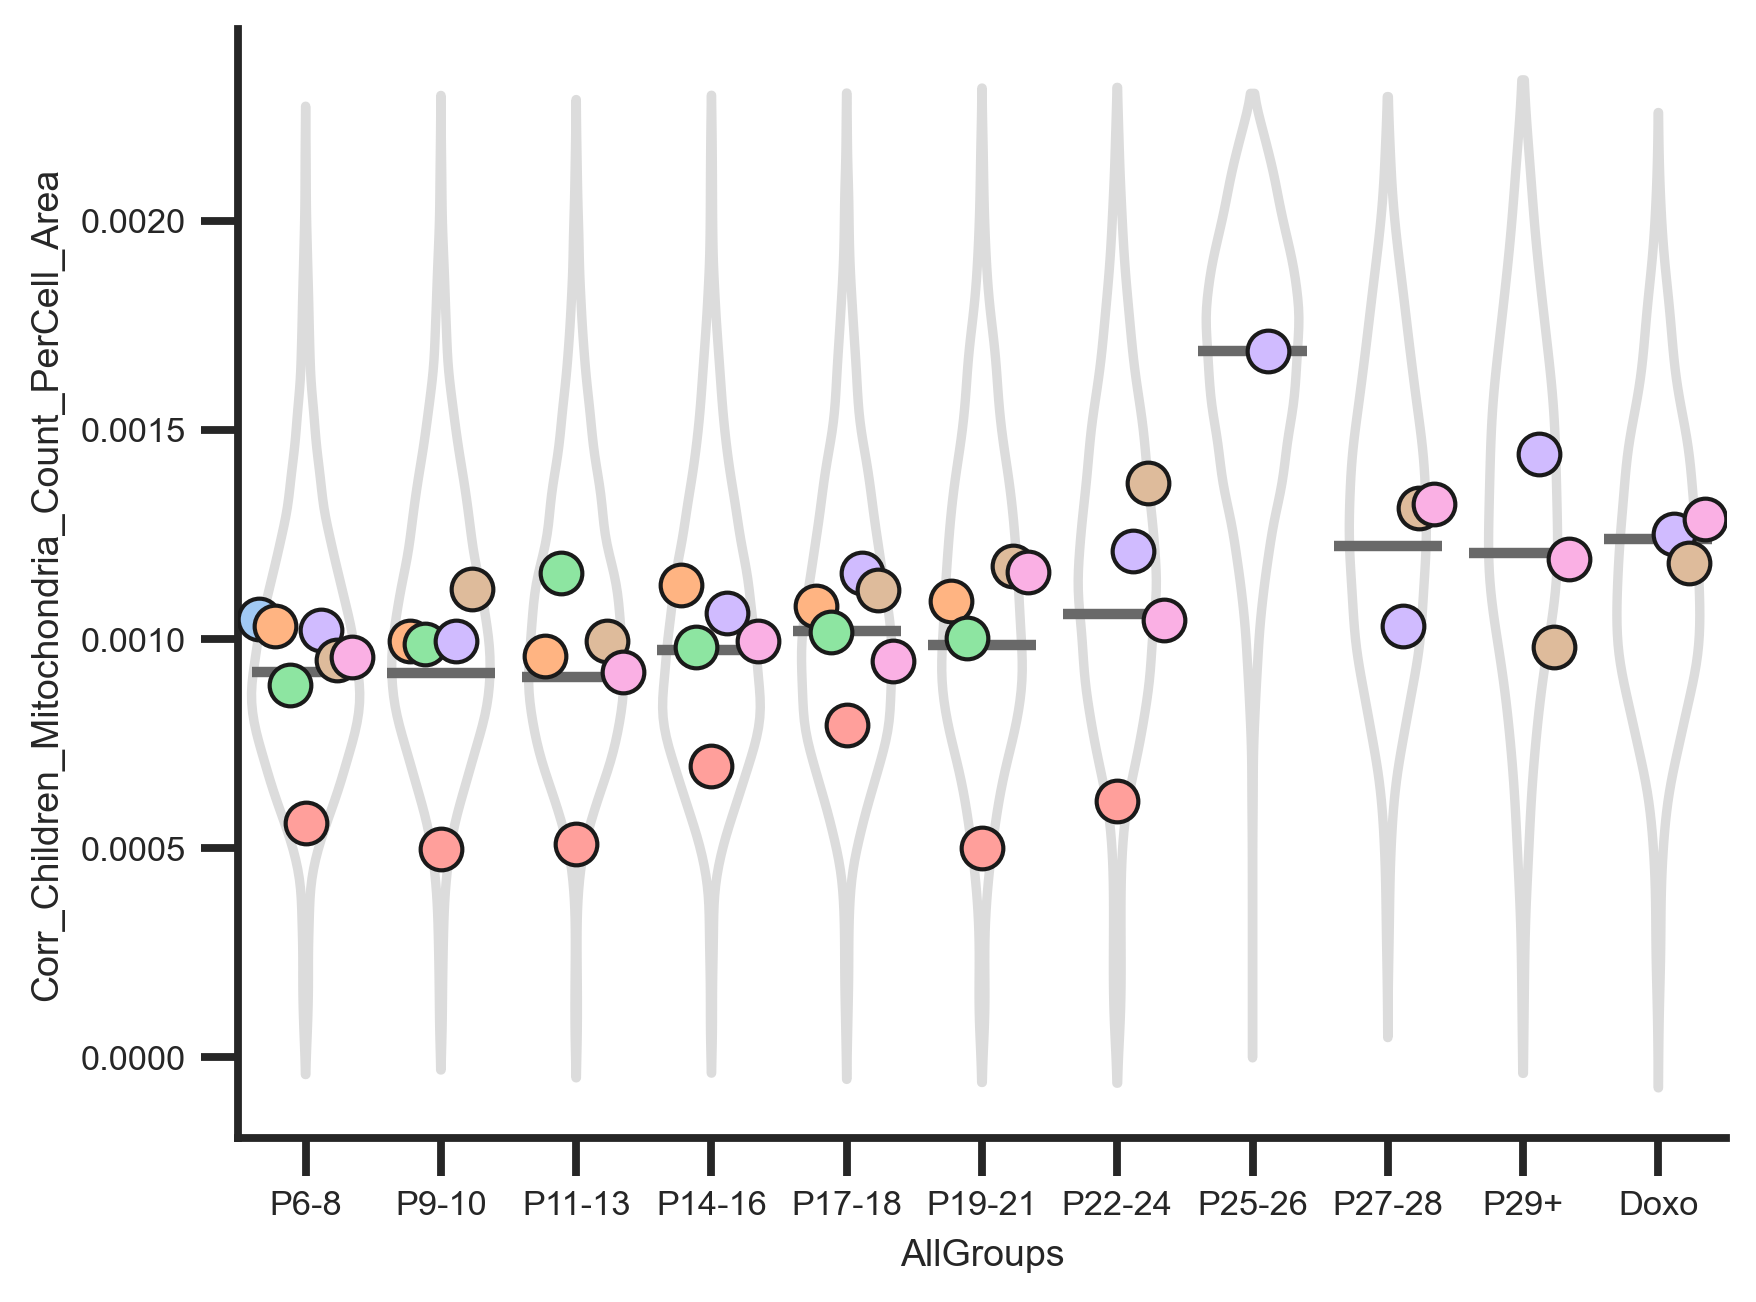

In [34]:
order = get_all_group_order()
feature_meas = 'Corr_Children_Mitochondria_Count_PerCell_Area'
ylabel = "Mitochondria per cell area ratio"


group = 'AllGroups'
replicates = 'Replicate_Number'
pairs = getpairs(norm_cell_df_mitolyso, group, order)
this_df = combined_cell_df_mitolyso_merged.copy()
pallete = "pastel"
remove_outliers = True

feature_df = make_single_feature_df_1(this_df, group=group, feature=feature_meas, replicates='Replicate_Number')
group_avg_df = average_groups_by_plate_1(feature_df, x_value=group, y_value=feature_meas, replicates='Replicate_Number')
group_avg_df_pivot = average_groups_pivot(group_avg_df, x_value=group, y_value=feature_meas, replicates='Replicate_Number')

if remove_outliers is True:
    feature_df = remove_outliers_iqr(feature_df)
    display(feature_df)

display(feature_df)
display(group_avg_df)
display(group_avg_df_pivot)

sns.set_theme(style="ticks")
#sns.set_context("notebook", font_scale=1.9)

plt.figure(figsize=(12, 8))
sns.set_context("talk", font_scale=0.5)
plt.figure(dpi=300)


sns.violinplot(data=feature_df, x=group,
            y=feature_meas,
            order=order,
            fill = False,
            color= 'gainsboro',
            cut=1,
            native_scale=True,
            linecolor='k',
            inner= None,
            #inner_kws=dict(box_width = 5)
            )

ax = sns.swarmplot(data=group_avg_df, x=group,
            y=feature_meas,
            hue = replicates,
            order=order,
            palette=pallete,
            size=10, 
            edgecolor="k", 
            linewidth=1,
            dodge=0.5)

#use a boxplot to draw the mean line - thinking outside the box :)
sns.boxplot(data = group_avg_df, x = group,
            y = feature_meas,
            showmeans=True,
            meanline=True,
            meanprops={'color': 'dimgray', 'ls': '-', 'lw': 2.5},
            medianprops={'visible': False},
            whiskerprops={'visible': False},
            zorder=1,
            showfliers=False,
            showbox=False,
            showcaps=False,
            ax = ax)

ax.legend_.remove()

sns.despine()
plt.gcf()#.set_size_inches(10, 6)
plt.xlabel(group)
if ylabel == None:
    plt.ylabel(feature_meas.replace('_', ' '))


from statannotations.Annotator import Annotator
from statannotations.stats.StatTest import StatTest

# Extract the data for each group

# Perform the one-way ANOVA test

# Print the results
anova = oneway_anova(group_avg_df, group, feature_meas)

tukey_results = tukey_test_1(group_avg_df, test_groups=group, feature=feature_meas)
display(tukey_results)

annotator = Annotator(ax, pairs, data=group_avg_df_pivot, order=order)
annotator.configure(text_format='star', loc='inside', verbose = 2, hide_non_significant=True)
annotator.set_pvalues_and_annotate(tukey_results['p-value'])

plt.savefig("plots/new_plots/" + feature_meas + '_anova_superviolinplot.png', dpi=300)
plt.show()



#### For Kruskal-Walis
```python
sns.catplot(data=feature_df, x='Passage Group',
            y=feature_meas,
            hue = "Replicate_Number",
            order=order,
            fill = False,
            palette='Set2',
            kind = 'violin',
            inner = None)

sns.boxplot(data=feature_df, x='Passage Group',
            y=feature_meas,
            hue = "Replicate_Number",
            order=order,
            showfliers = False,
            palette='Set2')

ax = sns.swarmplot(data=group_avg_df, x='Passage Group',
            y=feature_meas,
            hue = "Replicate_Number",
            order=order)

sns.despine()
plt.gcf().set_size_inches(10, 6)
plt.xlabel('Passage Group')
plt.ylabel(feature_meas.replace('_',' '))
plt.ylim(-0.5, 6)


from statannotations.Annotator import Annotator
from statannotations.stats.StatTest import StatTest

annotator = Annotator(ax, pairs, data=group_avg_df_pivot, x='Passage Group', y=feature_meas, order=order) 0 
annotator.configure(test='Kruskal', text_format='star', loc='inside')
annotator.apply_and_annotate()


plt.savefig(feature_meas + '_boxplot.png', dpi=300)
```


## Make the plots - nonparametric
### ytitles
ytitle = "Distance of Mitochondria from Cell Center"
ytitle = "Distance of Lysosomes from Cell Center"
"Number of Mitochondria per Cell (Relative to Control)"
ytitle = "Number of Lysosomes per Cell (Relative to Control)"
ytitle = "Total Normalized Mitochondrial Area Per Cell"
ytitle = "Normalized # of Mitochondrial Endpoints
ytitle = "Normalized # of Mitochondrial Trunks"
ytitle = "Mean Length of Mitochondrial Network"
ytitle = "Mean # of Mitochondrial Branches"
ytitle = "Minimum Distance of Mitochondria from Cell"
ytitle = "Mean Total Mitochondrial Area"
ytitle = "Mean Mitochondrial Size"
ytitle = "Mean Total Mitochondrial Perimeter"
ytitle = "Mean Mitochondrial Granularity"
ytitle = "Total Mitochondrial Intensity"
ytitle = "Mean LAMP1 Intensity Per Lysosome"
ytitle = "Mean Mitochondria Intensity Per Cell"
ytitle = "Mean Lysosome Intensity Per Cell"
ytitle = "Total LAMP1 Intensity"
ytitle = "Total Mitochondrial Intensity"
ytitle = "Mean MitoTracker Intensity"
ytitle = "Ratio of Mitochondria Area to Cell Area"
ytitle = "Ratio of Lysosome Area to Cell Area"
ytitle = "MitoTracker Intensity Per Cell Area"
ytitle = "LAMP1 Intensity Per Cell Area"
ytitle = "Lysosomal Circularity"
ytitle = "MitoTracker Intensity Per Cell Area"

,AllGroups,Corr_Area_PerCell_Ratio_Lysosomes,Replicate_Number
0,Doxo,1.576195,6
1,Doxo,1.609021,6
2,Doxo,1.204061,6
3,Doxo,0.825053,6
4,Doxo,1.163890,6
...,...,...,...
55642,P6-8,1.722366,7
55643,P6-8,0.264864,7
55644,P6-8,0.181628,7
55645,P6-8,0.600992,7


/Users/allielas/HTP_fibroblasts_mitolyso/helpers.py:562: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  def average_groups_pivot(df, x_value, y_value, replicates):


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

P17-18 vs. P29+: Kruskal-Wallis independent samples (pairwise between groups), P_val:2.014e-02 Stat=5.400e+00
P6-8 vs. P29+: Kruskal-Wallis independent samples (pairwise between groups), P_val:1.670e-02 Stat=5.727e+00


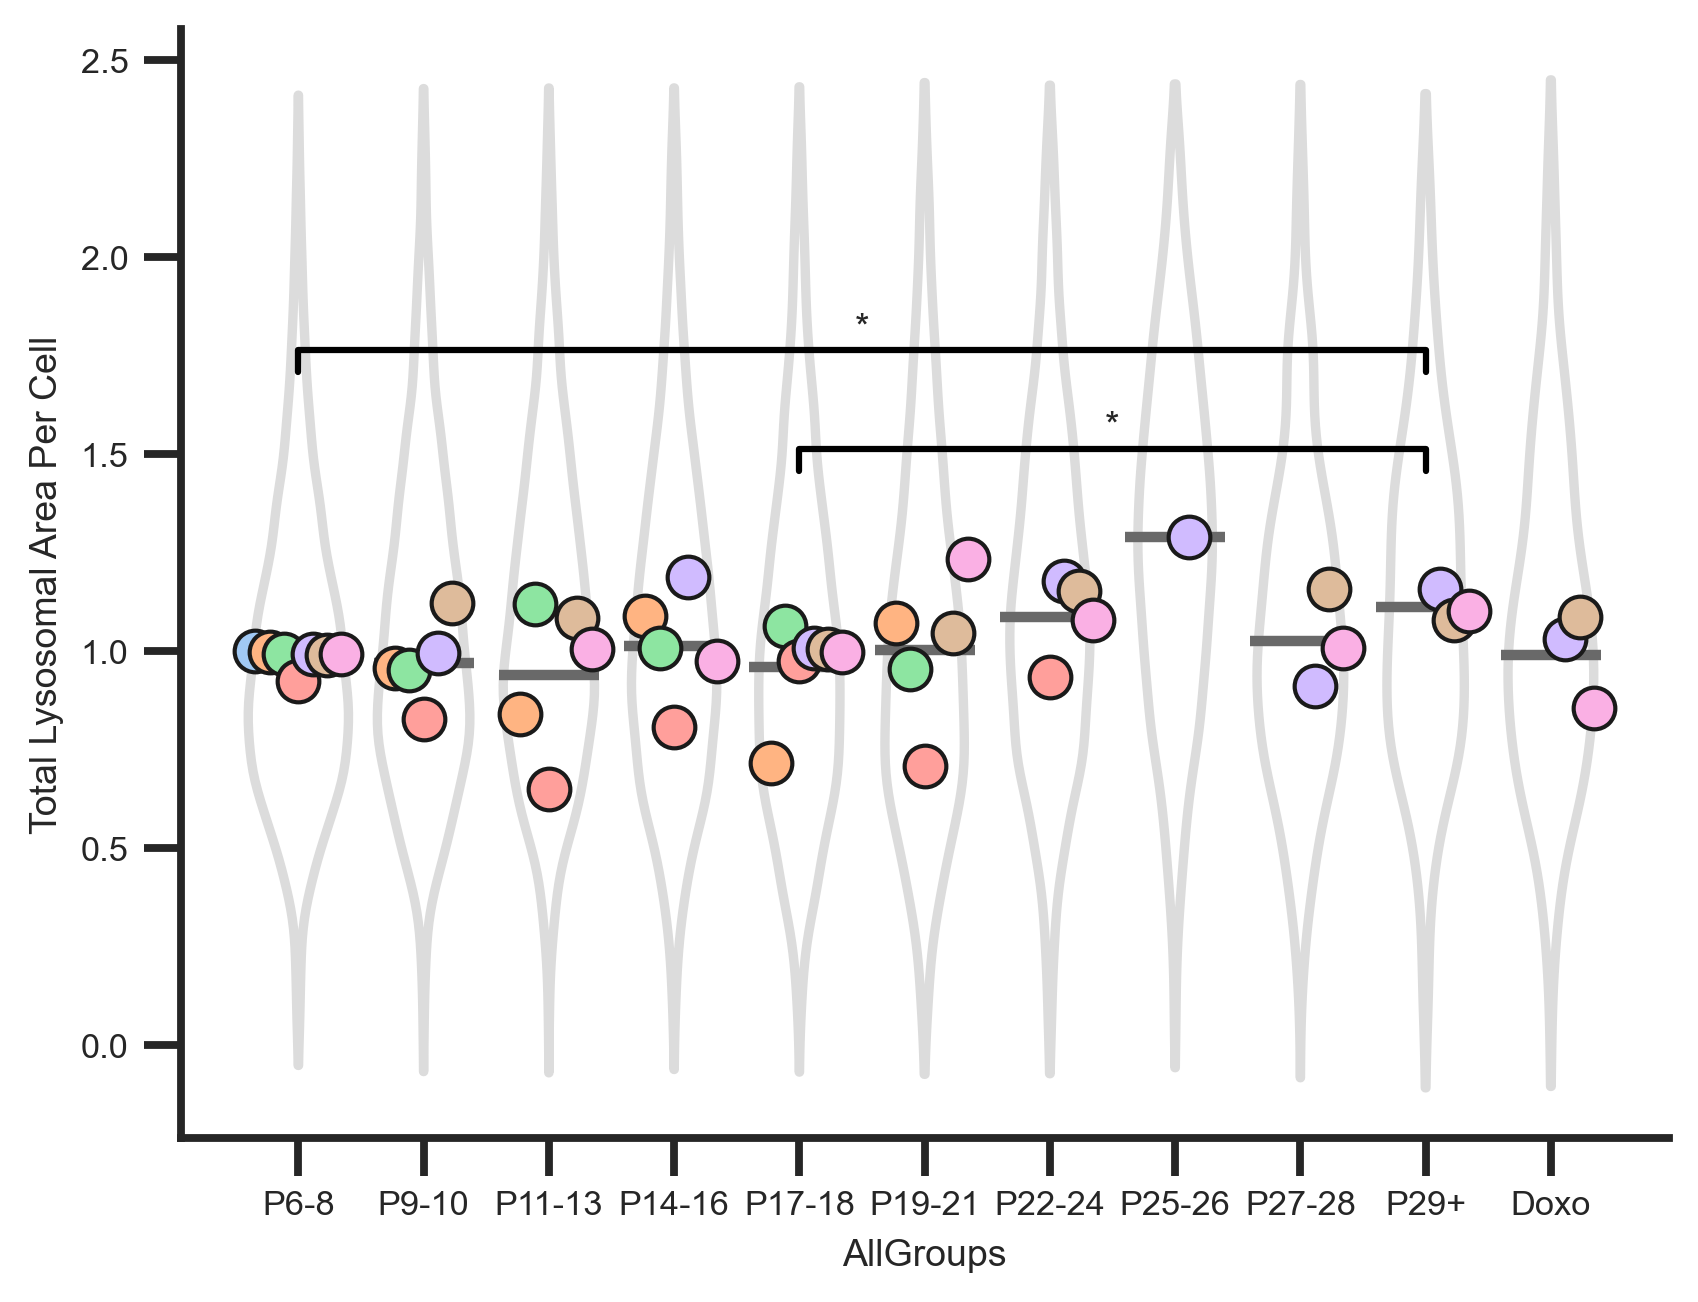

In [60]:
#Nonparametric Function version

#Try this too
#norm_cell_df_mitolyso["Mean_MitoEnds_ObjectSkeleton_NumberNonTrunkBranches_MtSkltn_PerCell"] = norm_cell_df_mitolyso["Mean_MitoEnds_ObjectSkeleton_NumberNonTrunkBranches_MtSkltn"] * norm_cell_df_mitolyso["Children_MitoEnds_Count"]
#feature_meas = "Mean_MitoEnds_ObjectSkeleton_NumberNonTrunkBranches_MtSkltn_PerCell"

#feature_meas = "Mean_MitoEnds_ObjectSkeleton_NumberNonTrunkBranches_MtSkltn"
feature_meas = "Corr_Area_PerCell_Ratio_Lysosomes" #- RadialDistribution_MeanFrac_MitoTracker_2of4 RadialDistribution_MeanFrac_MitoTracker_3of4 RadialDistribution_MeanFrac_MitoTracker_4of4"
ytitle = "Total Lysosomal Area Per Cell"

order = get_all_group_order()

if feature_meas == 'AreaShape_Area':
    norm_cell_df_mitolyso[feature_meas] = normalize_to_control(norm_cell_df_mitolyso,feature_meas)
    ytitle = "Mean Cell Size"



ylimit = None# (-1,2)

pallete = "pastel"
#pallete = "pastel" 
remove_outliers = True

def remove_outliers_iqr(df, cols = None):
    if cols is None:
        cols = df.select_dtypes('number').columns  # limits to a (float), b (int) and e (timedelta)
    df_sub = df.loc[:, cols]

    iqr = df_sub.quantile(0.75, numeric_only=False) - df_sub.quantile(0.25, numeric_only=False)
    
    #calculate  extreme outlisers by dividing median by iqr
    lim = np.abs((df_sub - df_sub.median()) / iqr) < 2.22

    # replace outliers with nan
    df.loc[:, cols] = df_sub.where(lim, np.nan)
    df.dropna(subset=cols, inplace=True) # drop rows with NaN in numerical columns
    return df

def make_superplot_with_kruskal(data, group, feature_meas, replicates, ytitle = None, pallete='pastel', ylim = None, order = None, remove_outliers = False):
    
    if order is None:
        order = data[group].dropna().unique().tolist()
    
    if ytitle is None:
        ytitle = feature_meas.replace('_', ' ')

       
    feature_df = make_single_feature_df(data, group=group, feature=feature_meas, replicates=replicates)
     
    if remove_outliers is True:
        feature_df = remove_outliers_iqr(feature_df)
        display(feature_df)
        
    
    pairs = getpairs(feature_df, group, order)


    group_avg_df = average_groups_by_plate(feature_df, x_value=group, y_value=feature_meas, replicates=replicates)
    group_avg_df_pivot = average_groups_pivot(group_avg_df, x_value=group, y_value=feature_meas, replicates=replicates)

    sns.set_theme(style="ticks")
    sns.set_context("talk", font_scale=0.5)

    plt.figure(dpi=300)

    sns.violinplot(data=feature_df, x=group,
                y=feature_meas,
                order=order,
                fill = False,
                color= 'gainsboro',
                cut=1,
                native_scale=True,
                linecolor='k',
                inner= None,
                #inner_kws=dict(box_width = 5)
                )

    ax = sns.swarmplot(data=group_avg_df, x=group,
                y=feature_meas,
                hue = replicates,
                order=order,
                palette=pallete,
                size=10, 
                edgecolor="k", 
                linewidth=1,
                dodge=0.5)
    
    #use a boxplot to draw the mean line - thinking outside the box :)
    sns.boxplot(data = group_avg_df, x = group,
                y = feature_meas,
                showmeans=True,
                meanline=True,
                meanprops={'color': 'dimgray', 'ls': '-', 'lw': 2.5},
                medianprops={'visible': False},
                whiskerprops={'visible': False},
                zorder=1,
                showfliers=False,
                showbox=False,
                showcaps=False,
                ax = ax)

    ax.legend_.remove()

    sns.despine()
    plt.gcf()#.set_size_inches(10, 6)
    plt.xlabel(group)
    plt.ylabel(ytitle)
    plt.ylim(ylim)

    from statannotations.Annotator import Annotator
    annotator = Annotator(ax, pairs, data=group_avg_df_pivot, order=order) 
    annotator.configure(test='Kruskal', 
                        text_format='star', 
                        #pvalue_format = 'simple',
                        loc='inside', 
                        hide_non_significant = True,
                        color = 'black',
                        verbose = 2)
    annotator.apply_and_annotate()

    plt.savefig("plots/new_plots/" + feature_meas + '_superviolinplot.png', dpi=300)
    plt.show()
    


make_superplot_with_kruskal(norm_cell_df_mitolyso, 'AllGroups', feature_meas, 'Replicate_Number', ytitle, pallete, ylimit, order=order, remove_outliers=True)

/Users/allielas/HTP_fibroblasts_mitolyso/helpers.py:530: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  # Extract relevant results


ValueError: Missing x value(s) `"Doxo", "P22-24"` in None (specified in `order`)

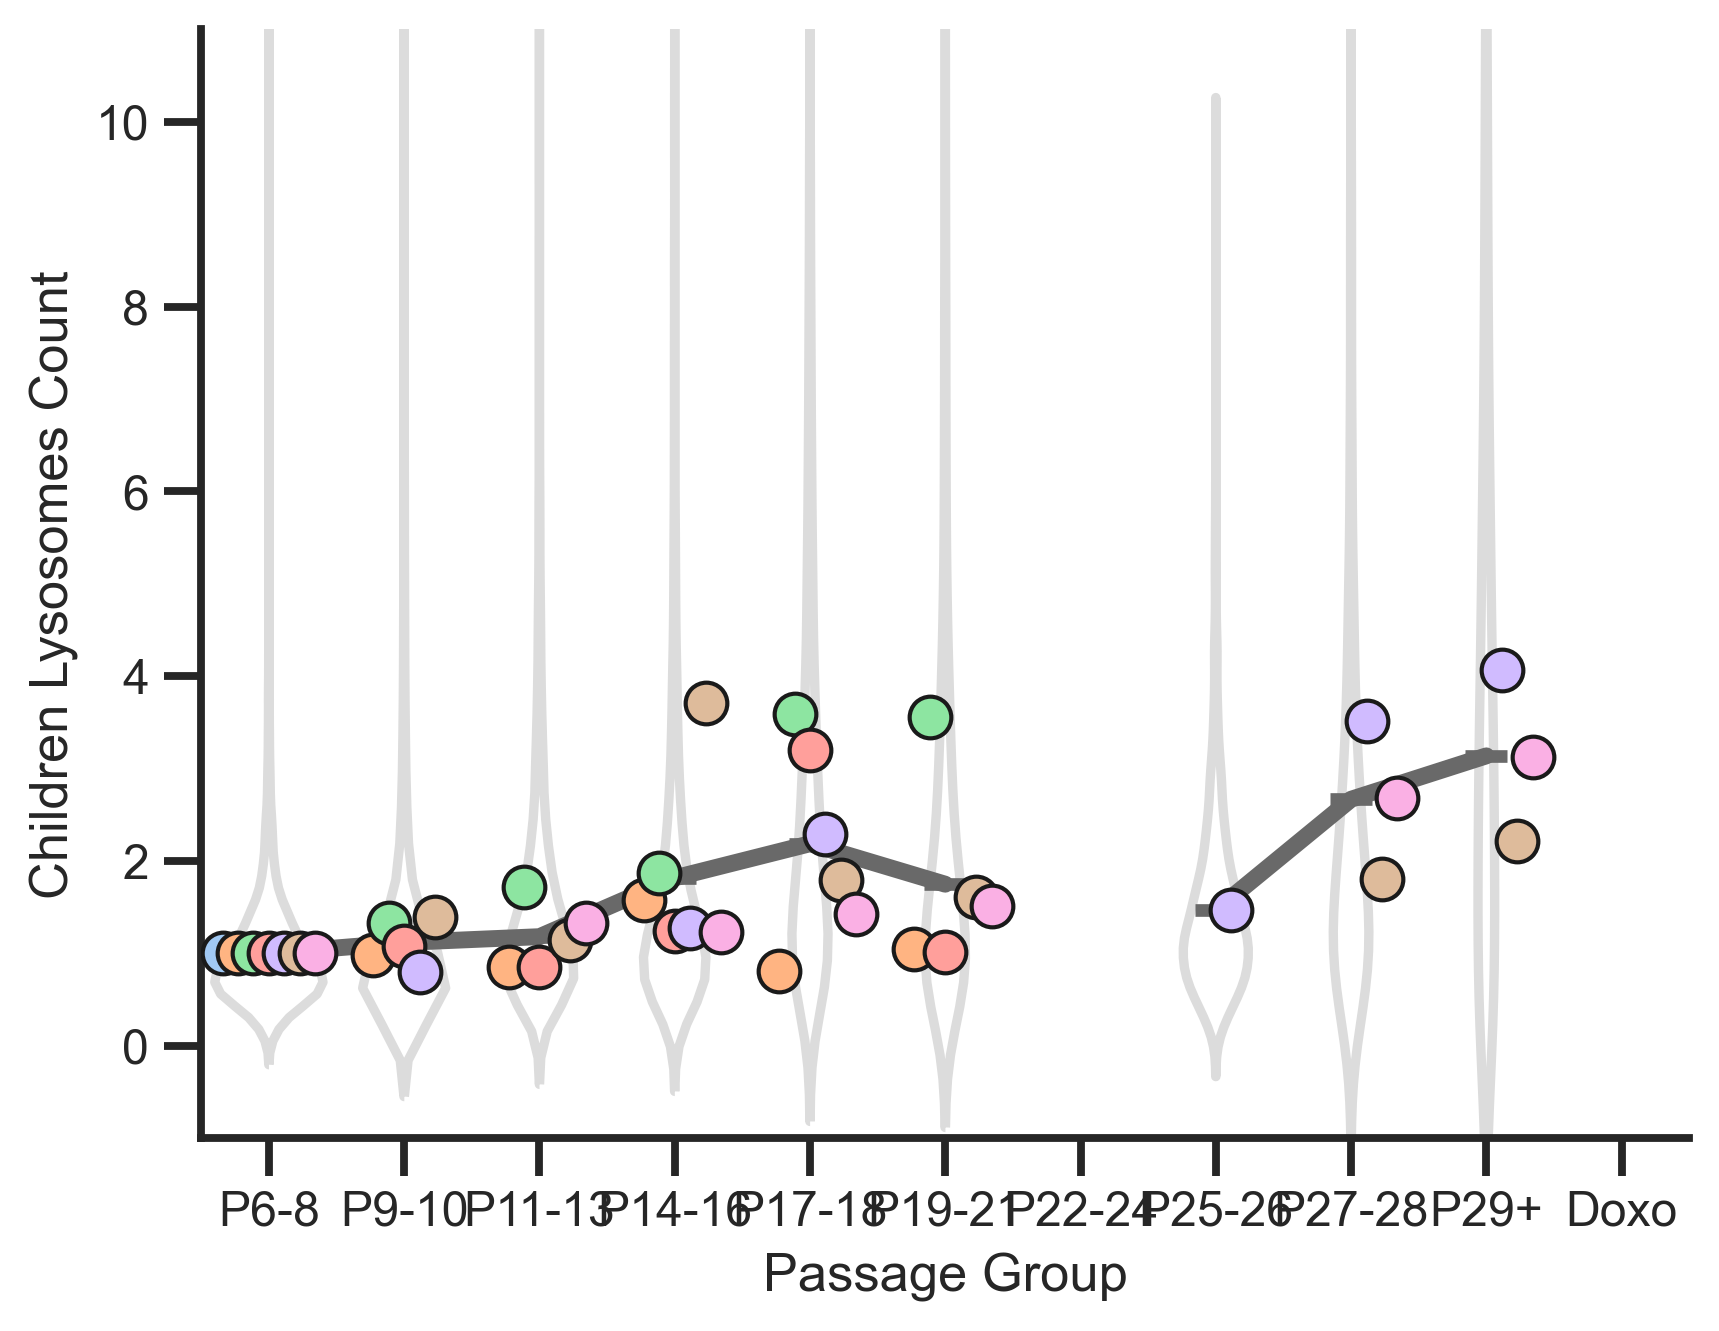

In [ ]:
#Nonparametric version
feature_meas = 'Children_Lysosomes_Count'
order = ['P6-8', 'P9-10', 'P11-13', 'P14-16', 'P17-18', 'P19-21', 'P22-24','P25-26','P27-28','P29+', 'Doxo']

feature_df = make_single_feature_df_1(norm_cell_df_mitolyso, group='Passage Group', feature=feature_meas, replicates='Replicate_Number')
pairs = getpairs(feature_df, 'AllGroups', order)

#Remove the doxo for now1 replicate
feature_df = feature_df[feature_df['AllGroups'] != "Doxo"]

group_avg_df = average_groups_by_plate_1(feature_df, x_value='Passage Group', y_value=feature_meas, replicates='Replicate_Number')
group_avg_df_pivot = average_groups_pivot(group_avg_df, x_value='Passage Group', y_value=feature_meas, replicates='Replicate_Number')

sns.set_theme(style="ticks")
sns.set_context("talk", font_scale=0.7)

plt.figure(dpi=300)

sns.violinplot(data=feature_df, x='Passage Group',
            y=feature_meas,
            #hue = "Passage Group",
            order=order,
            fill = False,
            color= 'gainsboro',
            #palette = 'Set2',
            cut=2,
            native_scale=True,
            linecolor='k',
            inner= None,
            #inner_kws=dict(box_width = 5)
            )

ax = sns.swarmplot(data=group_avg_df, x='Passage Group',
            y=feature_meas,
            hue = "Replicate_Number",
            order=order,
            palette='pastel',
            size=10, 
            edgecolor="k", 
            linewidth=1,
            dodge=0.5)

sns.pointplot(data=group_avg_df, x='Passage Group',
              y=feature_meas,
              #hue='Replicate_Number',
              color='dimgray',
              order=order,
              dodge=False,
              markers='_',
              linestyle=None,
              errorbar=None,
              ax=ax)

ax.legend_.remove()

sns.despine()
plt.gcf()#.set_size_inches(10, 6)
plt.xlabel('Passage Group')
plt.ylabel(feature_meas.replace('_',' '))
plt.ylim(-1,11)

from statannotations.Annotator import Annotator
annotator = Annotator(ax, pairs, data=group_avg_df_pivot, order=order) 
annotator.configure(test='Kruskal', 
                    text_format='star', 
                    loc='inside', 
                    hide_non_significant = True,
                    color = 'black',
                    verbose = 2)
annotator.apply_and_annotate()

plt.savefig(feature_meas + '_superviolinplot.png', dpi=300)
plt.show()

### To export the normalized csv:


In [ ]:

norm_cell_df_mitolyso.to_csv(os.path.join('All_Cell_w_metadata_normalized.csv'), index=False)

#  Old anaylysis code - with plotly
```python
boxplot(df, # dataframe name: mito_df, nuclei_df, image_df, outline_df, lysosomes_df
        'Variable', # the variable you wanna plot, column name
        'Y Title',# name of your y-axis (custom)
        'Time Point',#name of your x-axis (custom)
        'Red', # color of the boxes
        save=True, # if wanna save change to False to True, False is default
        save_name='_boxplot.png') #specify the name of the plot that you save

```

## The clustering zone

In [ ]:
from sklearn.decomposition import PCA
filter_key = 'LAMP1'
filtered_features = list(filter(lambda x: filter_key in x,cell_features))

ordered_cell = cell_df.sort_values(
  by='Time', 
  ascending=True)
ordered_cell['Time']=ordered_cell['Time'].astype("string")
X = ordered_cell[filtered_features]

pca = PCA()
components = pca.fit_transform(X)
labels = {
    str(i): f"PC {i+1} ({var:.1f}%)"
    for i, var in enumerate(pca.explained_variance_ratio_ * 100)
}

fig = px.scatter_matrix(
    components,
    labels=labels,
    dimensions=range(4),
    color=ordered_cell["Time"]
)
fig.update_traces(diagonal_visible=False)
fig.show()

In [ ]:
from sklearn.decomposition import PCA
filter_key = '_MitoTracker'
filtered_features = list(filter(lambda x: filter_key in x,cell_features))

ordered_cell = cell_df.sort_values(
  by='Time', 
  ascending=True)
ordered_cell['Time']=ordered_cell['Time'].astype("string")
X = ordered_cell[filtered_features]

pca = PCA(n_components=3)
components = pca.fit_transform(X)

fig = px.scatter_3d(components, x=0, y=1,z=2, color=ordered_cell['Time'] , labels = {
    str(i): f"PC {i+1} ({var:.1f}%)"
    for i, var in enumerate(pca.explained_variance_ratio_ * 100)
})
fig.show()

In [ ]:
from sklearn.manifold import TSNE
filter_key = 'Entropy_LAMP1'
filtered_features = list(filter(lambda x: filter_key in x,cell_features))

ordered_cell = cell_df.sort_values(
  by='Time', 
  ascending=True)
ordered_cell['Time']=ordered_cell['Time'].astype("string")
X = ordered_cell[filtered_features]

tsne = TSNE(n_components=2, random_state=0)
projections = tsne.fit_transform(X)

fig = px.scatter(
    projections, x=0, y=1,
    color=ordered_cell['Time']
)
fig.show()

In [ ]:
ordered_nuc = combined_nuclei_df.sort_values(
  by='Time', 
  ascending=True)

ordered_nuc['Passage Group'] = ordered_nuc['PassageNumber'].apply(passage_group)

feature = 'AreaShape_Solidity'

fig = px.box(ordered_nuc, x=feature, y='Passage Group', color = 'Passage Group', labels={
                     feature: feature.strip('_'),
                     'Passage Group': 'Passage Group'})

fig.show()